# Stochastic Convolutional Neural Network (SCNN)

In [1]:
import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
from torx import (
    CompiledSamplePCircuit,
    DiscretePCircuit,
    PCNOT,
    PJUMP,
    PNOT,
    PReset,
    SampleSimulator,
)
from tqdm import tqdm

In [2]:
N_CIRCUIT = 4
N_PBITS = N_CIRCUIT * N_CIRCUIT


def generate_bars_and_stripes(n, seed=0):
    patterns, labels = [], []
    seen = set()
    for bits in range(2**n):
        row_vals = [(bits >> i) & 1 for i in range(n)]
        img = np.array([np.full(n, v) for v in row_vals])
        key = img.tobytes()
        if key not in seen:
            seen.add(key)
            patterns.append(img)
            labels.append(0)
    for bits in range(2**n):
        col_vals = [(bits >> i) & 1 for i in range(n)]
        img = np.column_stack([np.full(n, v) for v in col_vals])
        key = img.tobytes()
        if key not in seen:
            seen.add(key)
            patterns.append(img)
            labels.append(1)

    patterns = np.array(patterns, dtype=np.int32)
    labels = np.array(labels, dtype=np.int32)

    rng = np.random.default_rng(seed)
    perm = rng.permutation(len(labels))
    return patterns[perm], labels[perm]


patterns, labels = generate_bars_and_stripes(N_CIRCUIT)
n_total = len(patterns)
n_train = int(0.7 * n_total)

x_train = jnp.array(patterns[:n_train].reshape(-1, N_PBITS))
y_train = jnp.array(labels[:n_train], dtype=jnp.float32)
x_val = jnp.array(patterns[n_train:].reshape(-1, N_PBITS))
y_val = jnp.array(labels[n_train:], dtype=jnp.float32)

print(f"Total patterns: {n_total}")
print(f"Train: {len(y_train)}, Val: {len(y_val)}")

Total patterns: 30
Train: 21, Val: 9


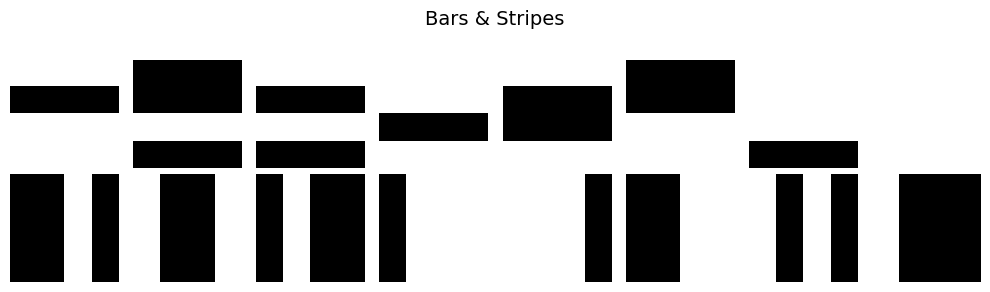

In [3]:
fig, axes = plt.subplots(2, 8, figsize=(10, 3))
for cls, (row, name) in enumerate(zip(axes, ["Bars", "Stripes"])):
    examples = patterns[labels == cls][:8]
    for ax, img in zip(row, examples):
        ax.imshow(img, cmap="gray_r", vmin=0, vmax=1)
        ax.axis("off")
    row[0].set_ylabel(name, fontsize=12, rotation=0, labelpad=40)
plt.suptitle("Bars & Stripes", fontsize=14)
plt.tight_layout()
plt.show()

In [4]:
N_READOUT = 8


def build_scnn_circuit(n_pbits, n_readout=N_READOUT):
    gates, param_map, active, shared_idx = [], [], list(range(n_pbits)), 0

    while len(active) > n_readout:
        n = len(active)

        conv_base = shared_idx
        shared_idx += 4
        for start in [0, 1]:
            for i_idx in range(start, n - 1, 2):
                i, j = active[i_idx], active[i_idx + 1]
                gates.append(PJUMP(jnp.array(0.0), [i, j]))
                param_map.append(conv_base + 1)
                gates.append(PJUMP(jnp.array(0.0), [j, i]))
                param_map.append(conv_base + 1)
                gates.append(PReset(jnp.array(0.0), i))
                param_map.append(conv_base + 2)
                gates.append(PNOT(jnp.array(0.0), j))
                param_map.append(conv_base + 3)

        pool_base = shared_idx
        shared_idx += 1
        n_pairs = n // 2
        pool_pairs = [(active[2 * i], active[2 * i + 1]) for i in range(n_pairs)]
        for src, sink in pool_pairs:
            gates.append(PCNOT(jnp.array(0.0), [src, sink]))
            param_map.append(pool_base)
        new_active = [sink for _, sink in pool_pairs]
        if n % 2 == 1:
            new_active.append(active[-1])
        active = new_active

    circuit = DiscretePCircuit(gates)
    print(f"Gates: {len(gates)}, Shared params: {shared_idx}, Readout pbits: {active}")
    return circuit, np.array(param_map), active, shared_idx


circuit, param_map, readout_sites, num_params = build_scnn_circuit(N_PBITS)

Gates: 68, Shared params: 5, Readout pbits: [1, 3, 5, 7, 9, 11, 13, 15]


In [5]:
# draw_circuit(circuit)

In [6]:
NUM_SAMPLES = 1000
sim = SampleSimulator(diff_method="param_shift_inf", num_samples=NUM_SAMPLES)
template = SampleSimulator.build_circuit(circuit)


class SCNN(eqx.Module):
    params: jax.Array
    _template: CompiledSamplePCircuit
    _param_map: jax.Array
    _readout_sites: list = eqx.field(static=True)
    linear: eqx.nn.Linear

    def __call__(self, x, key):
        full_thetas = self.params[self._param_map][:, None]
        circuit = eqx.tree_at(lambda c: c.thetas, self._template, full_thetas)
        ev = sim.expval_all(circuit, x, key)
        features = jnp.array([ev[s] for s in self._readout_sites])
        return jax.nn.sigmoid(self.linear(features))


model = SCNN(
    params=jnp.ones(num_params),
    _template=template,
    _param_map=jnp.array(param_map),
    _readout_sites=readout_sites,
    linear=eqx.nn.Linear(len(readout_sites), "scalar", key=jax.random.key(0)),
)

## Training

In [7]:
@eqx.filter_value_and_grad
def loss_fn(model, x_batch, y_batch, key):
    keys = jax.random.split(key, len(x_batch))
    preds = jax.vmap(model)(x_batch, keys)
    preds = jnp.clip(preds, 1e-7, 1 - 1e-7)
    bce = -(y_batch * jnp.log(preds) + (1 - y_batch) * jnp.log(1 - preds))
    return jnp.mean(bce)


@eqx.filter_jit
def train_step(model, opt_state, x_batch, y_batch, key):
    loss, grads = loss_fn(model, x_batch, y_batch, key)
    updates, opt_state = optimizer.update(
        grads, opt_state, eqx.filter(model, eqx.is_array)
    )
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss


@eqx.filter_jit
def evaluate(model, x, y, key):
    keys = jax.random.split(key, len(x))
    preds = jax.vmap(model)(x, keys)
    preds = jnp.clip(preds, 1e-7, 1 - 1e-7)
    loss = jnp.mean(-(y * jnp.log(preds) + (1 - y) * jnp.log(1 - preds)))
    acc = jnp.mean((preds > 0.5) == y)
    return loss, acc

In [8]:
optimizer = optax.adam(1e-1)
opt_state = optimizer.init(eqx.filter(model, eqx.is_inexact_array))
key = jax.random.key(0)

train_losses, val_losses = [], []
train_accs, val_accs = [], []

n_epochs = 100
pbar = tqdm(range(n_epochs))
for epoch in pbar:
    key, train_key, eval_key_t, eval_key_v = jax.random.split(key, 4)
    model, opt_state, t_loss = train_step(model, opt_state, x_train, y_train, train_key)

    t_loss_eval, t_acc = evaluate(model, x_train, y_train, eval_key_t)
    v_loss, v_acc = evaluate(model, x_val, y_val, eval_key_v)

    train_losses.append(t_loss_eval)
    val_losses.append(v_loss)
    train_accs.append(t_acc)
    val_accs.append(v_acc)

    if epoch % 20 == 0:
        pbar.set_description(
            f"loss={t_loss_eval:.3f} val={v_loss:.3f} acc={t_acc:.2f} v_acc={v_acc:.2f}"
        )

  0%|          | 0/100 [00:00<?, ?it/s]

loss=0.057 val=0.052 acc=1.00 v_acc=1.00: 100%|██████████| 100/100 [00:10<00:00,  9.71it/s]


## Results

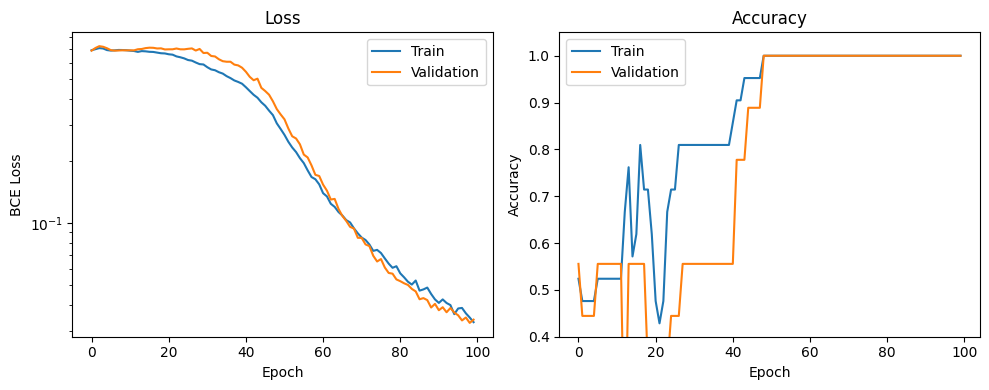

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(train_losses, label="Train")
ax1.plot(val_losses, label="Validation")
ax1.set_xlabel("Epoch")
ax1.set_yscale("log")
ax1.set_ylabel("BCE Loss")
ax1.legend()
ax1.set_title("Loss")

ax2.plot(train_accs, label="Train")
ax2.plot(val_accs, label="Validation")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_ylim(0.4, 1.05)
ax2.legend()
ax2.set_title("Accuracy")

plt.tight_layout()
plt.show()